# Aliasing demo: synthetic small-scale input map

This notebook isolates aliasing in downgrade workflows using a synthetic map whose power is concentrated mostly above the target output bandlimit.

Instead of an artificial narrow spike, the input spectrum is a broad smooth bump centered at high multipoles. This makes the example closer to a realistic map with substantial small-scale structure.

If the output NSIDE is `nside_out`, then the target harmonic content should live below `lmax_out = 3*nside_out - 1`. Any large-scale structure created by downgrade from the unresolved high-ell part is aliasing.

In [1]:
from pathlib import Path
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

In [2]:
def _round_sig(x, sig=2):
    if x == 0 or not np.isfinite(x):
        return float(x)
    return float(np.round(x, sig - int(np.floor(np.log10(abs(x)))) - 1))

def rounded_limits(*maps, q=(0.5, 99.5)):
    vals = np.concatenate([m[np.isfinite(m)] for m in maps])
    lo, hi = np.percentile(vals, q)
    vmin = _round_sig(float(lo), sig=2)
    vmax = _round_sig(float(hi), sig=2)
    if vmin == vmax:
        vmax = vmin + 1.0
    return vmin, vmax

def proj_panels(maps, titles, cmap='RdBu_r', q=(0.5, 99.5), ncol=3, xsize=2200, symmetric=False):
    vmin, vmax = rounded_limits(*maps, q=q)
    if symmetric:
        lim = max(abs(vmin), abs(vmax))
        vmin, vmax = -lim, lim
    print(f'vmin={vmin}, vmax={vmax}')
    n = len(maps)
    ncol = min(ncol, n)
    nrow = int(np.ceil(n / ncol))
    plt.figure(figsize=(6.8*ncol, 4.8*nrow))
    for i, (m, t) in enumerate(zip(maps, titles), start=1):
        hp.projview(
            m,
            sub=(nrow, ncol, i),
            title=t,
            min=vmin,
            max=vmax,
            cmap=cmap,
            graticule=True,
            xsize=xsize,
            cb_orientation='horizontal',
        )
    plt.tight_layout()

def moll_diff_panels(diff_maps, titles, unit='', q=(0.2, 99.8)):
    vmin, vmax = rounded_limits(*diff_maps, q=q)
    lim = max(abs(vmin), abs(vmax))
    vmin, vmax = -lim, lim
    print(f'moll diff scale: vmin={vmin}, vmax={vmax}')
    n = len(diff_maps)
    plt.figure(figsize=(6.8*n, 4.8))
    for i, (m, t) in enumerate(zip(diff_maps, titles), start=1):
        hp.mollview(m, sub=(1, n, i), title=t, min=vmin, max=vmax, cmap='RdBu_r', unit=unit)
        hp.graticule()
    plt.tight_layout()

## Build a map with a broad high-ell bump

The synthetic input map is generated at high resolution, with most of its power placed above the output bandlimit in a broad smooth feature rather than a sharp line.

This gives a more realistic stress test: the correct target-bandlimited output is still strongly suppressed, but the setup no longer depends on an extreme spectral spike.

In [3]:
nside_in = 256
nside_out = 32
lmax_in = 3 * nside_in - 1
lmax_out = 3 * nside_out - 1

ell = np.arange(lmax_in + 1)
ell0 = lmax_out + 55
sigma_ell = 28.0
# Broad, smooth high-ell bump with a soft low-ell cutoff.
bump = np.exp(-0.5 * ((ell - ell0) / sigma_ell) ** 2)
cut = 1.0 / (1.0 + np.exp(-(ell - (lmax_out + 10)) / 4.0))
cl_hi = bump * cut
cl_hi[:2] = 0.0
cl_hi /= cl_hi.max()
# Add a small random floor instead of clipping to zero so the spectrum stays realistic.
rng_floor = np.random.default_rng(2026)
floor = 1.0e-4 * 10.0 ** rng_floor.uniform(-0.3, 0.3, size=cl_hi.size)
floor[:2] = 0.0
cl_hi = np.maximum(cl_hi, floor)

np.random.seed(4321)
alm_in = hp.synalm(cl_hi, lmax=lmax_in)
m_in = hp.alm2map(alm_in, nside=nside_in, lmax=lmax_in, pixwin=False)

alm_ref = hp.resize_alm(alm_in, lmax_in, lmax_in, lmax_out, lmax_out)
m_ref = hp.alm2map(alm_ref, nside=nside_out, lmax=lmax_out, pixwin=False)

print('Input bump center ell =', int(ell0))
print('Input bump width sigma_ell =', sigma_ell)
print('Output bandlimit lmax_out =', lmax_out)
print('Injected floor amplitude ~ 1e-4 of peak with random jitter')
print('Reference low-resolution map std =', np.std(m_ref))

Input bump center ell = 150
Input bump width sigma_ell = 28.0
Output bandlimit lmax_out = 95
Injected floor amplitude ~ 1e-4 of peak with random jitter
Reference low-resolution map std = 0.803241478580098


## Input spectrum

This panel shows the high-resolution input spectrum together with the output bandlimit. The signal is a broad smooth bump concentrated above the target low-resolution band, so the test still highlights aliasing without relying on an extreme spike.

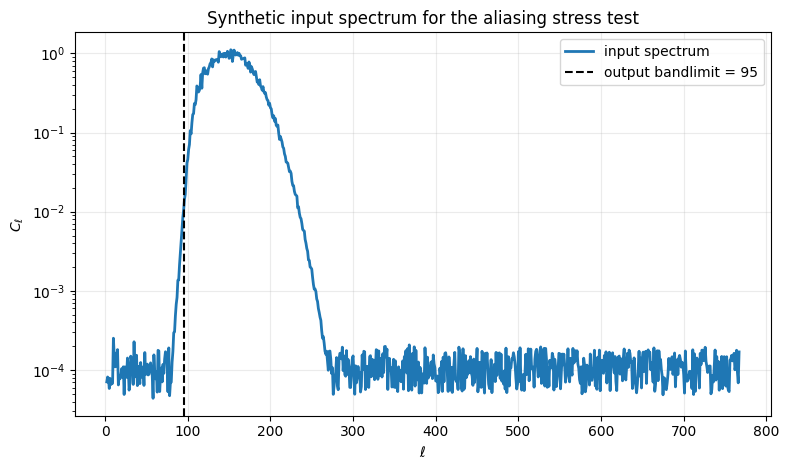

In [4]:
cl_in = hp.anafast(m_in, lmax=lmax_in)
plt.figure(figsize=(8, 4.8))
plt.semilogy(ell[2:], cl_in[2:], label='input spectrum', linewidth=2.0)
plt.axvline(lmax_out, color='black', linestyle='--', linewidth=1.5, label=f'output bandlimit = {lmax_out}')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_\ell$')
plt.title('Synthetic input spectrum for the aliasing stress test')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

In [5]:
m_ud = hp.ud_grade(m_in, nside_out=nside_out)
m_harm = hp.harmonic_ud_grade(m_in, nside_out=nside_out, use_pixel_weights=False)
m_smooth_ud = hp.ud_grade(hp.smoothing(m_in, fwhm=np.radians(30/60)), nside_out=nside_out)

vmin=-100.0, vmax=100.0


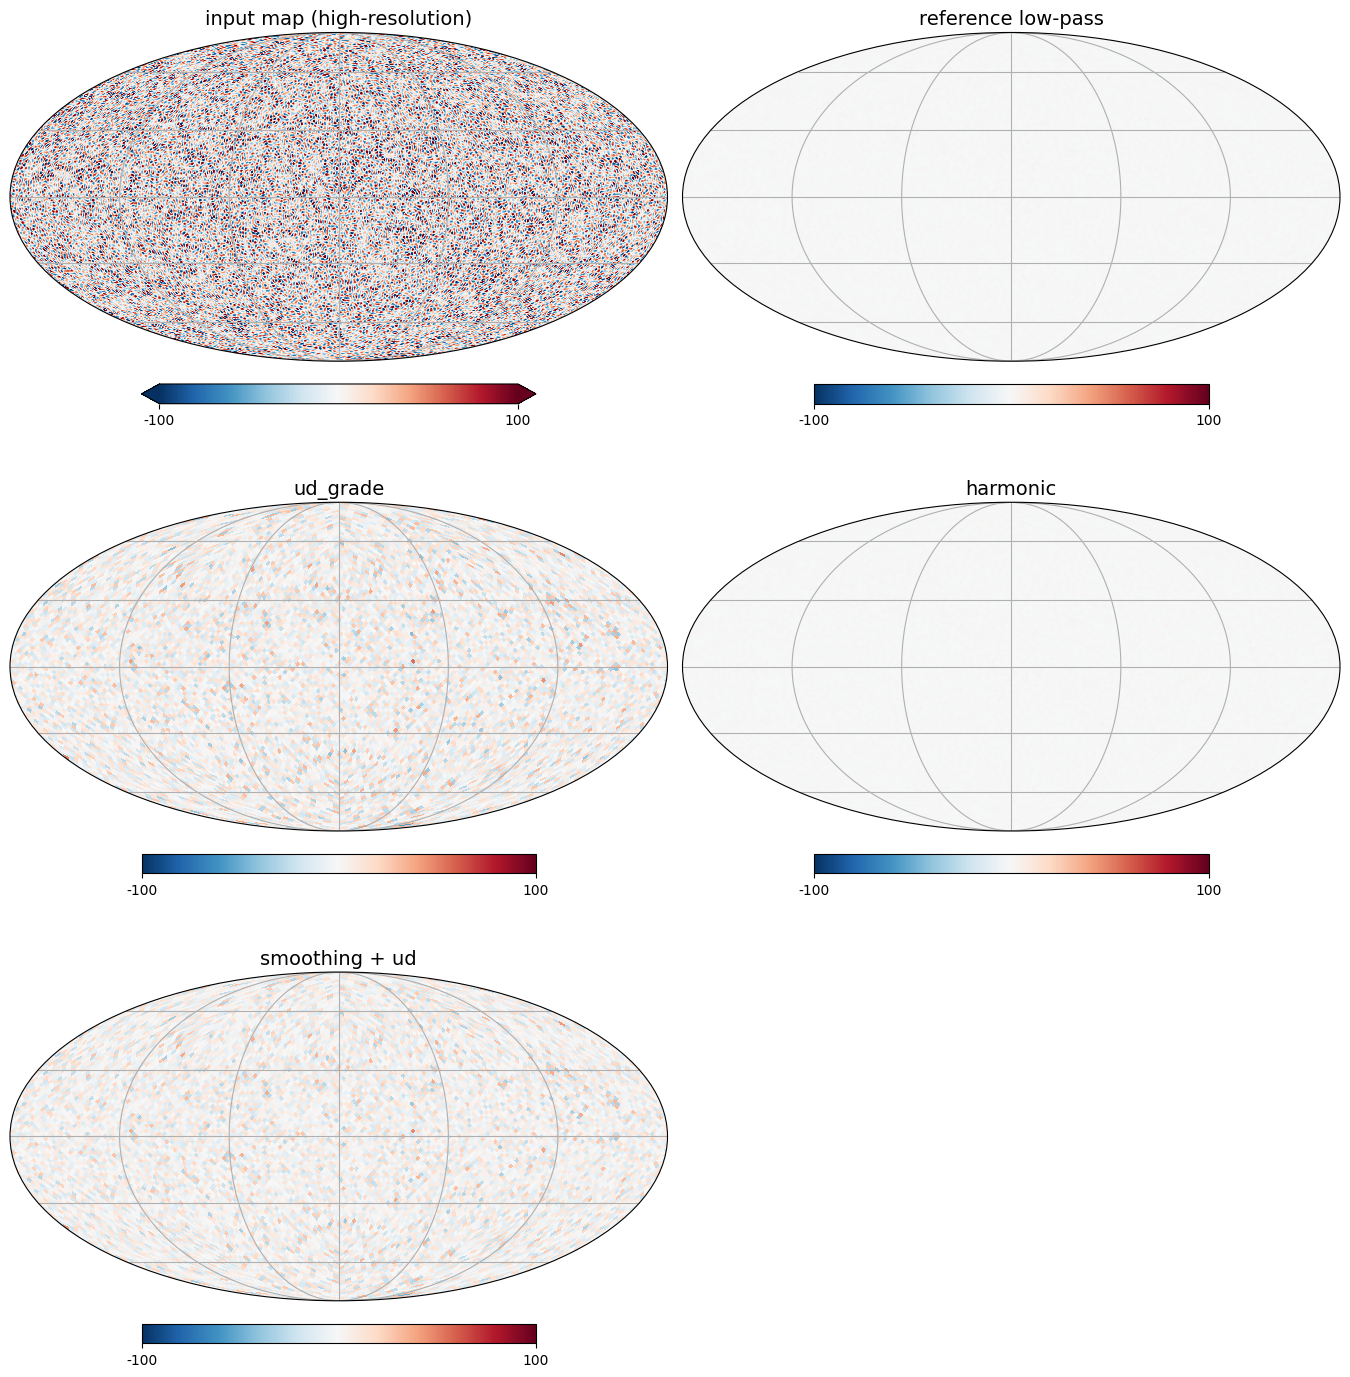

In [6]:
proj_panels(
    [m_in, m_ref, m_ud, m_harm, m_smooth_ud],
    ['input map (high-resolution)', 'reference low-pass', 'ud_grade', 'harmonic', 'smoothing + ud'],
    cmap='RdBu_r',
    q=(0.5, 99.5),
    ncol=2,
)

## Residual maps relative to the target-bandlimited reference

Because the reference low-resolution map should be close to zero here, these residuals directly visualize spurious low-resolution structure created by each method.

vmin=-36.0, vmax=36.0


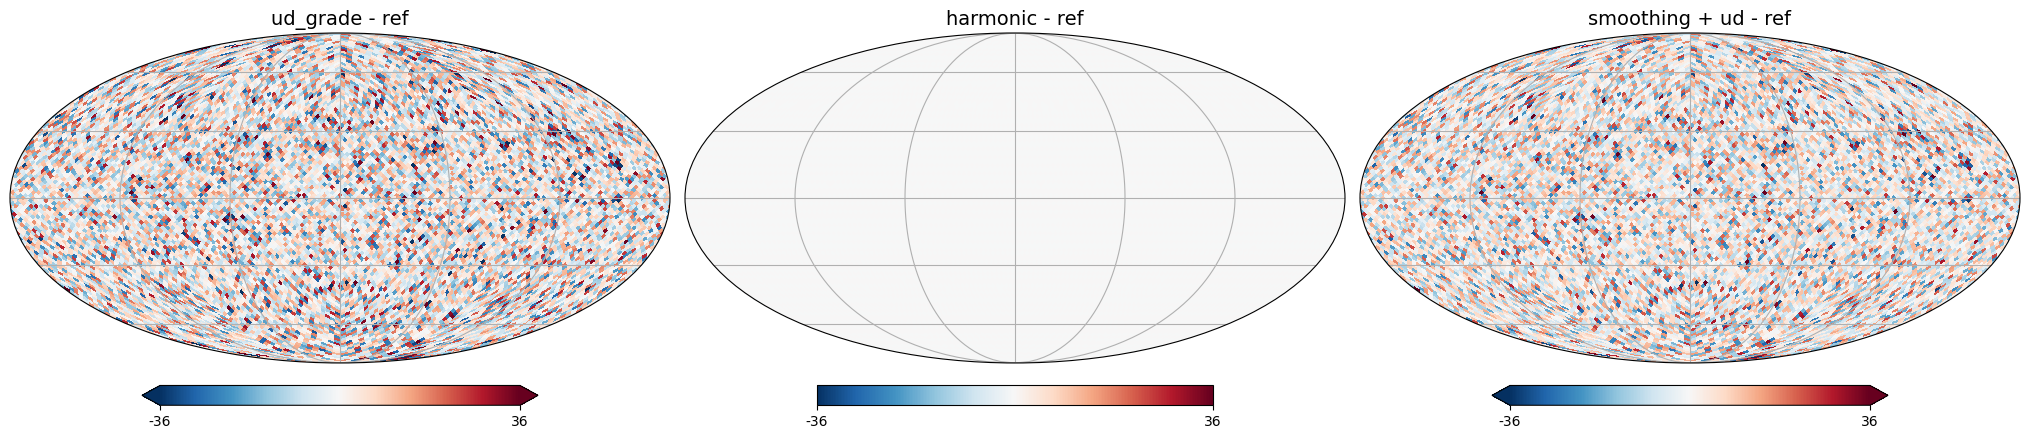

In [7]:
diff_ud = m_ud - m_ref
diff_harm = m_harm - m_ref
diff_smooth_ud = m_smooth_ud - m_ref

proj_panels(
    [diff_ud, diff_harm, diff_smooth_ud],
    ['ud_grade - ref', 'harmonic - ref', 'smoothing + ud - ref'],
    cmap='RdBu_r',
    q=(0.1, 99.9),
    symmetric=True,
)

moll diff scale: vmin=-36.0, vmax=36.0


/tmp/ipykernel_13654/1876002638.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


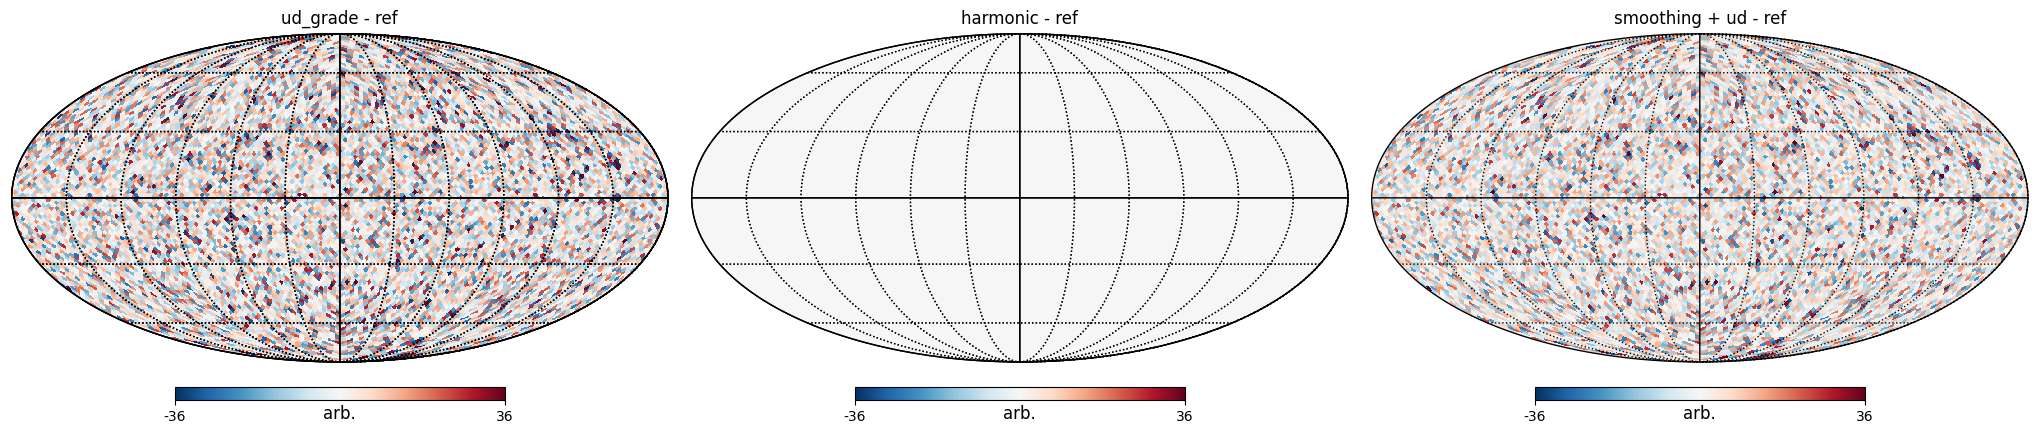

In [8]:
moll_diff_panels(
    [diff_ud, diff_harm, diff_smooth_ud],
    ['ud_grade - ref', 'harmonic - ref', 'smoothing + ud - ref'],
    unit='arb.',
    q=(0.1, 99.9),
)

## Low-ell spectra of the downgraded maps

Because the input power is concentrated above the output bandlimit, the correct low-resolution spectrum should be strongly suppressed. Any substantial low-ell power that appears after downgrade is leakage from unresolved scales.

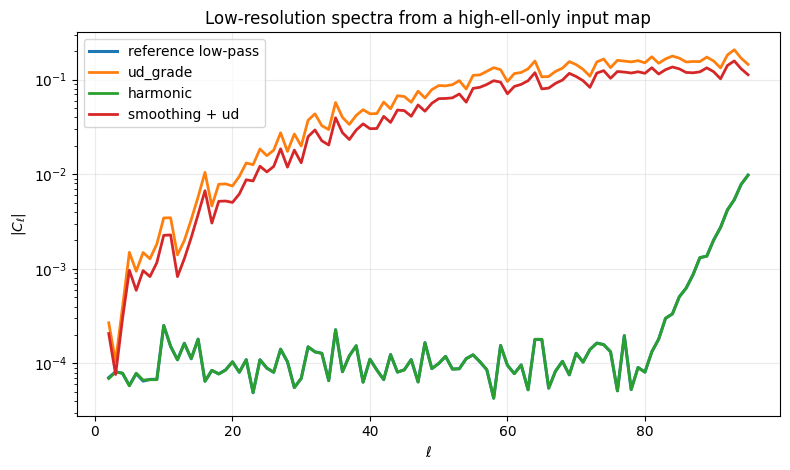

In [9]:
cl_ref = hp.anafast(m_ref, lmax=lmax_out)
cl_ud = hp.anafast(m_ud, lmax=lmax_out)
cl_harm = hp.anafast(m_harm, lmax=lmax_out)
cl_smooth_ud = hp.anafast(m_smooth_ud, lmax=lmax_out)
ell_out = np.arange(lmax_out + 1)

plt.figure(figsize=(8, 4.8))
plt.semilogy(ell_out[2:], np.abs(cl_ref[2:]), label='reference low-pass', linewidth=2.2)
plt.semilogy(ell_out[2:], np.abs(cl_ud[2:]), label='ud_grade', linewidth=2.0)
plt.semilogy(ell_out[2:], np.abs(cl_harm[2:]), label='harmonic', linewidth=2.0)
plt.semilogy(ell_out[2:], np.abs(cl_smooth_ud[2:]), label='smoothing + ud', linewidth=2.0)
plt.xlabel(r'$\ell$')
plt.ylabel(r'$|C_\ell|$')
plt.title('Low-resolution spectra from a high-ell-only input map')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

In [10]:
ref_norm = np.linalg.norm(cl_ref[2:])
if ref_norm == 0:
    ref_norm = 1.0

summary = {
    'ud_grade': {
        'map_rms': float(np.sqrt(np.mean(diff_ud**2))),
        'spec_l2': float(np.linalg.norm(cl_ud[2:] - cl_ref[2:])),
    },
    'harmonic': {
        'map_rms': float(np.sqrt(np.mean(diff_harm**2))),
        'spec_l2': float(np.linalg.norm(cl_harm[2:] - cl_ref[2:])),
    },
    'smoothing_plus_ud': {
        'map_rms': float(np.sqrt(np.mean(diff_smooth_ud**2))),
        'spec_l2': float(np.linalg.norm(cl_smooth_ud[2:] - cl_ref[2:])),
    },
}
summary

{'ud_grade': {'map_rms': 12.835661193102585, 'spec_l2': 0.982862124531665},
 'harmonic': {'map_rms': 0.0034702520306839958,
  'spec_l2': 5.554485209119251e-06},
 'smoothing_plus_ud': {'map_rms': 11.212290698619043,
  'spec_l2': 0.7413888736829912}}

## Conclusion

This notebook is a direct aliasing stress test with a synthetic map that has a broad small-scale power excess above the target output band.

The correct low-resolution content should be strongly suppressed. In this setup, any large-scale structure that appears after downgrade is leakage from unresolved scales. The method with the smallest residual map amplitude and the smallest low-ell spectrum is therefore the least alias-prone.